In [10]:
import cv2
import matplotlib.pyplot as plt

def recortar(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(contour)
    imagen_result = image[y:y+h, x:x+w]
    return imagen_result

In [48]:
unidades = [
  "cero",
  "uno",
  "dos",
  "tres",
  "cuatro",
  "cinco",
  "seis",
  "siete",
  "ocho",
  "nueve",
  "diez",
]

dec = [
  "once",
  "doce",
  "trece",
  "catorce",
  "quince",
]


decenas = [
  "dieci",
  "veinti",
  "treinta",
  "cuarenta",
  "cincuenta",
]

def ObtenerLiteral(num: int)->str:
  if(num < 0 or num >= 60):
    return None
  if(num == 0):
    return "cero"
  if(num <= 10):
    return unidades[num]
  un = num%10
  dc = num//10

  if(dc == 1 and un < 6):
    return dec[un-1]
  if(dc == 1 and un <= 9):
    return "dieci"+unidades[un]
  if(dc == 2 and un == 0):
    return "veinte"
  if(dc == 2 and un <= 9):
    return "venti"+unidades[un]
  if(dc <= 5 and un == 0):
    return decenas[dc-1]
  if(dc <= 5 and un <= 9):
    return decenas[dc-1] + " y " + unidades[un]

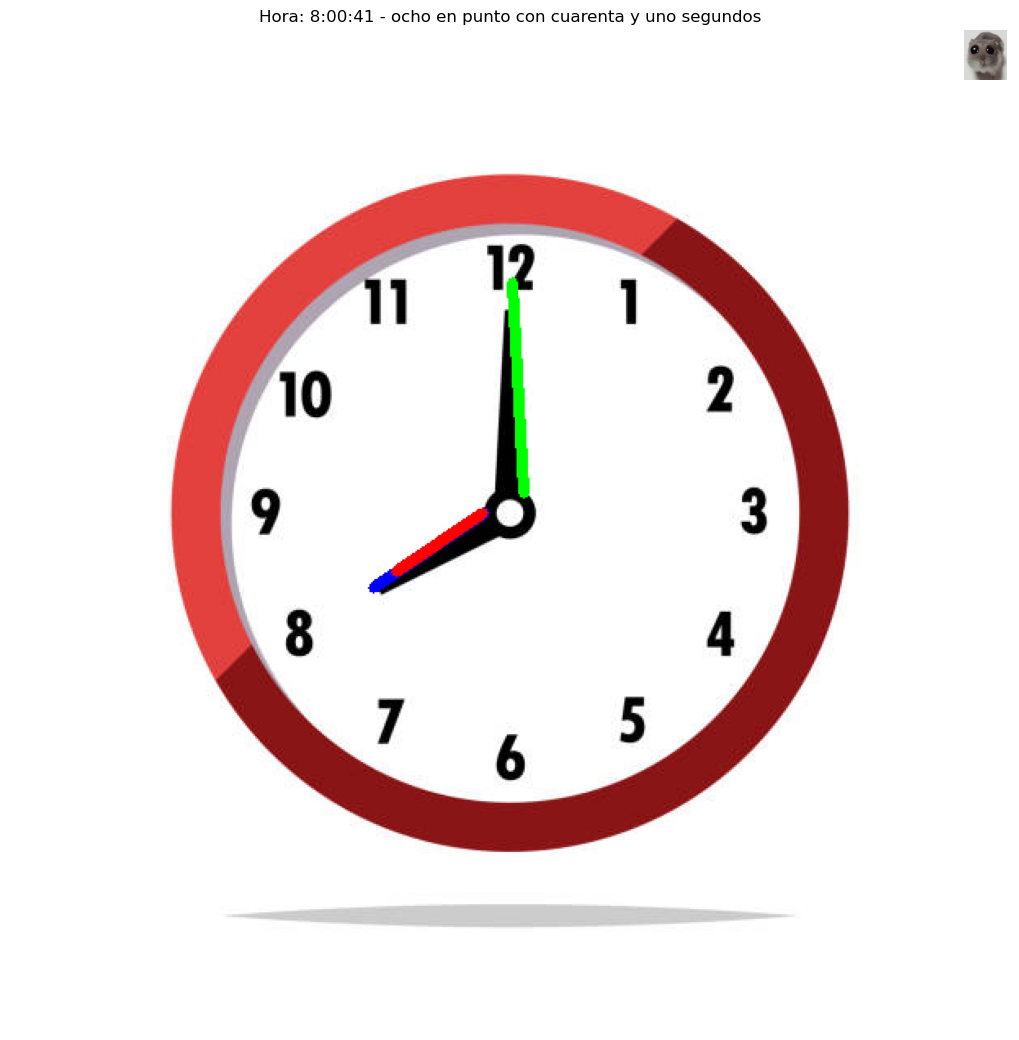

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


asd = cv2.cvtColor(cv2.imread("r.jpeg"),cv2.COLOR_BGR2RGB)

imagen_bgr = cv2.imread('reloj-2.jpeg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
imagen_rgb = recortar(imagen_rgb)

gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)


bordes = cv2.Canny(gris, 50, 150)

# Detección de líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=50, minLineLength=30, maxLineGap=5)


centro_x = gris.shape[1] // 2
centro_y = gris.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        # LINEAS CENTRO
        if distancia_centro < 100 and 50 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })
if len(manecillas) >= 2:
    # CORTO LARGO
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[-2]
    minutero = manecillas[-1]
    segundero = manecillas[0]
    
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)
    fraccion_hora = (horario['angulo'] / 30) % 12

    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    imagen_resultado = imagen_rgb.copy()
   # cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,(horario['puntos'][0], horario['puntos'][1]),(horario['puntos'][2], horario['puntos'][3]), (0, 0, 255), 5)  # horario azul
    cv2.line(imagen_resultado,(minutero['puntos'][0], minutero['puntos'][1]),(minutero['puntos'][2], minutero['puntos'][3]),(0, 255, 0), 5)  # minutero verde
    cv2.line(imagen_resultado,(segundero['puntos'][0], segundero['puntos'][1]),(segundero['puntos'][2], segundero['puntos'][3]),(255, 0, 0), 5)  # segundero rojo
    
    fig = plt.figure(figsize=(10, 10))
    ax_main = fig.add_axes([0, 0, 1, 1])  # [x0, y0, ancho, alto]
    ax_main.imshow(imagen_resultado)
    ax_main.set_title(f'Hora: {hora}:{minutos:02d}:{segundos:02d} - {ObtenerLiteral(hora)} {"en punto" if minutos == 0 else "y " + ObtenerLiteral(minutos) + " minutos" } con {ObtenerLiteral(segundos)} segundos')
    ax_main.axis('off')

    recuadro_ancho = 0.05
    recuadro_alto = 0.05
    recuadro_x = 1.0 - recuadro_ancho  
    recuadro_y = 1.0 - recuadro_alto   

    ax_inset = fig.add_axes([recuadro_x, recuadro_y, recuadro_ancho, recuadro_alto])
    ax_inset.imshow(asd)
    ax_inset.axis('off')  # Quitar ejes del recuadro

    plt.show()

    # plt.figure(figsize=(10, 10))
    # plt.imshow(imagen_resultado)
    # plt.title(f'Hora: {hora}:{minutos:02d}:{segundos:02d}')
    # plt.show()

